# **Exploring the Skies: Air Passenger Time Series Analysis**

In this notebook, we will explore the Air Passengers time series dataset, which represents the number of passengers traveling by plane each month from 1949 to 1960. We will learn how to load time series data from a CSV file and perform various analyses to uncover trends and patterns in air travel over the years.

We will start by loading and examining the dataset, followed by steps to handle and preprocess the data. This includes:

1. **Log Transformation:** To stabilize the variance in the data and convert multiplicative relationships into additive ones.
2. **Moving Averages:** To smooth out short-term fluctuations and highlight longer-term trends.
3. **Seasonal Decomposition:** To break down the series into its trend, seasonal, and residual components.
4. **Seasonal Adjustment:** To remove seasonal effects and provide a clearer view of the underlying trend.

By the end of this notebook, you will have a comprehensive understanding of how to apply time series analysis techniques to historical data. Join us as we delve into this fascinating dataset and uncover the trends in air travel during the mid-20th century.

# **Import necessary libraries:**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# **Loading and Displaying the DataFrame:**

In [6]:
# Load the dataset
file_path = '/content/drive/MyDrive/AirPassengers.csv'
air_passenger_df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
air_passenger_df.head()


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [7]:
# Display the type of each column
print(air_passenger_df.dtypes)


Month          object
#Passengers     int64
dtype: object


We see that the `Month` column is of type `object`, which means it is being read as a `string`. Additionally, there's an unnecessary index column in our dataset. *For time series data, dates should ideally be the index.*

**Understanding Parameters for Loading Time Series Data:**

We can use several parameters in the `read_csv` function to properly load the time series data:

* **`header`:** Specifies the row number to use as column names.
* **`index_col`:** Specifies the column to set as the index.
* **`parse_dates`:** Parses the specified column(s) as date(s).
* **`squeeze`:** Returns a Series if the parsed data only contains one column.

# **Loading the Time Series Data Correctly:**

We'll set the `Month` column as the index, parse it as dates, and ensure we retrieve a Series object containing the number of passengers.

In [8]:
# Load the dataset correctly
air_passengers_df = pd.read_csv(
    file_path,
    header=0,
    index_col=0,
    parse_dates=[0]
)



In [9]:
# Convert DataFrame to Series
airpass = air_passengers_df.squeeze()

# Display the first 5 lines of `airpass`
print(airpass.head())


Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64


By setting these parameters, we ensure that the `Month` column is treated as the index and parsed as dates. This way, we obtain a Series object where the index represents months from 1949 to 1960, and the values represent the number of passengers.

**Checking the Index of the Series:**

To ensure the series is indexed by calendar dates, we need to inspect the `index` attribute.

In [10]:
# Display the index of the series
print(airpass.index)

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)


The `index` attribute of a pandas Series or DataFrame stores the labels of the data. For time series data, these labels should be date objects, indicating that each data point corresponds to a specific point in time. The output shows that the index of our series is a `DatetimeIndex` with dates from January 1949 to December 1960. This confirms that the series is indexed by calendar dates, which is crucial for time series analysis.

**Display Time-Series**

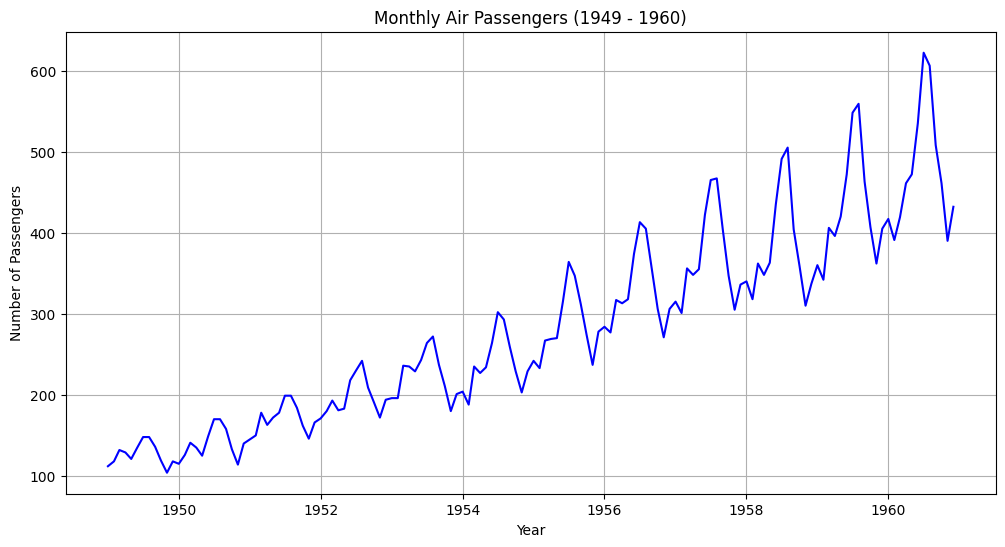

In [11]:
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(airpass, linestyle='-', color='blue')
plt.title('Monthly Air Passengers (1949 - 1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()


**Trend Analysis**

The plot of monthly air passengers from 1949 to 1960 displays a clear upward trend, indicating that the number of passengers traveling by air increased steadily over the years. This trend suggests a growing popularity and possibly increasing accessibility of air travel during this period.

**Key Observations:**

* The number of passengers starts around 100 in early 1949 and reaches over 600 by the end of 1960.
* This continuous increase reflects advancements in aviation technology, economic growth, and possibly post-war economic recovery.

**Seasonality**
The plot also exhibits a repeating pattern within each year, known as seasonality. There are regular fluctuations that seem to occur at the same time every year, indicating seasonal variations in air travel demand.

**Key Observations:**

* Peaks in the number of passengers are typically observed around mid-year, likely coinciding with summer holidays when people travel more frequently.
* There are noticeable dips in the number of passengers towards the end and the beginning of each year, which could be attributed to less travel during the winter months.

**Cyclic Patterns**
Apart from the clear seasonality, the data also might contain cyclic patterns—variations that occur at non-fixed intervals, influenced by longer-term economic cycles or changes in business and travel habits.

**Key Observations:**

* While seasonality shows up as consistent patterns year over year, cycles can be seen in the varying amplitudes of these peaks and troughs. Some years exhibit sharper increases or deeper declines compared to others.

# **Decomposing the Time Series Components**

Time series analysis involves breaking down the series into three key components: `trend`, `seasonality`, and `residuals` (or noise). This decomposition helps us understand the underlying patterns and fluctuations in the data.

The `statsmodels.tsa` submodule provides a function called `seasonal_decompose` for decomposing time series data.

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [13]:
# Apply the seasonal_decompose function
decomposition = seasonal_decompose(airpass, model='additive', period=12)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The `model` parameter specifies the type of decomposition. An `additive` model means that the time series is assumed to be a sum of the components (`trend + seasonality + noise`). The period parameter is set to 12, assuming a yearly seasonality for monthly data.

**Visualize the Decomposition:**

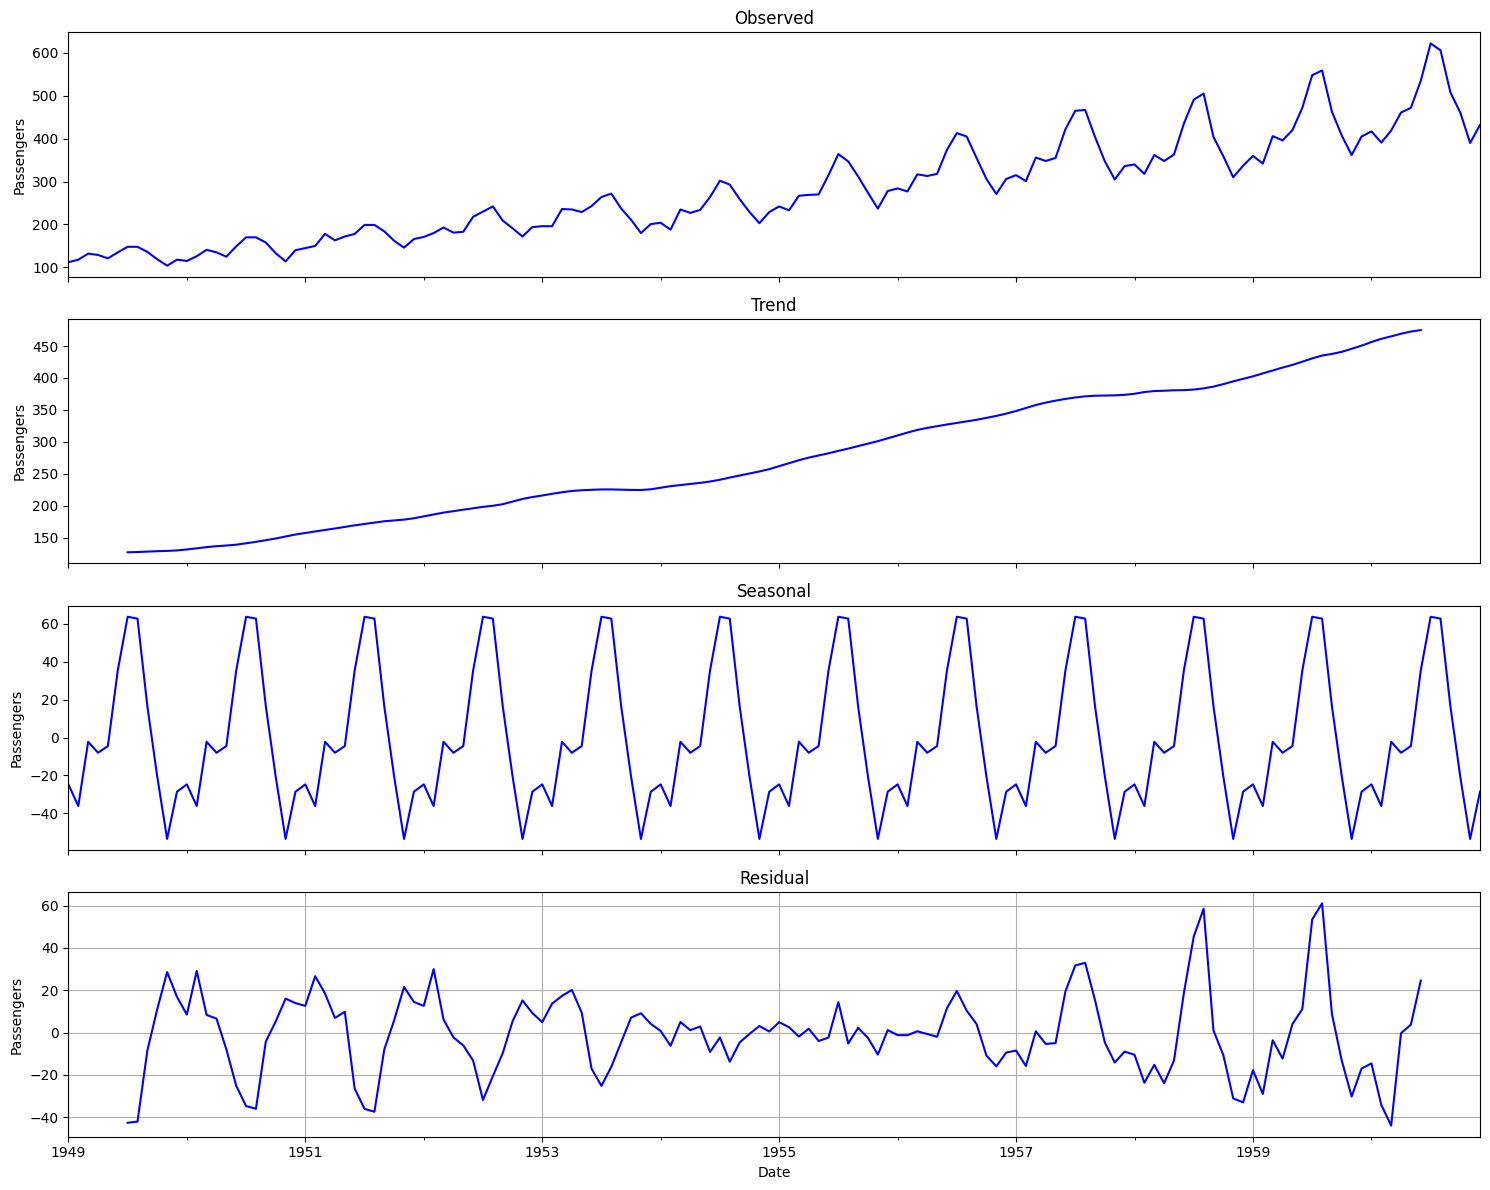

In [15]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

decomposition.observed.plot(ax=ax1, title='Observed', color='blue')
decomposition.trend.plot(ax=ax2, title='Trend', color='blue')
decomposition.seasonal.plot(ax=ax3, title='Seasonal', color='blue')
decomposition.resid.plot(ax=ax4, title='Residual', color='blue')

ax1.set_ylabel('Passengers')
ax2.set_ylabel('Passengers')
ax3.set_ylabel('Passengers')
ax4.set_ylabel('Passengers')
ax4.set_xlabel('Date')

plt.grid(True)
plt.tight_layout()
plt.show()

As we expected from the previous plot:

* **Trend:** The long-term progression of the series (shown as a smooth curve). The trend component shows a clear upward trajectory from 1949 to 1960.
* **Seasonal:** The repeating short-term cycle in the series. Here, it reveals a repeating pattern every year.
* **Residual:** The remaining variation after removing the trend and seasonality, indicating noise or irregularities. These residuals represent the random variations in the data that are not explained by the trend or seasonal patterns. Analyzing residuals can help identify outliers or unusual events impacting air travel.

**Additional Insight:**

The increasing seasonal effect over time suggests that a `multiplicative` model might be more appropriate. A multiplicative model is typically used when the amplitude of the seasonal effect varies with the level of the trend, which seems to be the case here. The seasonal_decompose function defaults to an additive model, but given the characteristics of the data, a multiplicative model could better capture the underlying patterns.

**Revised Code for Multiplicative Decomposition**

In [16]:
# Apply the seasonal_decompose function with a multiplicative model
decomposition_multiplicative = seasonal_decompose(airpass, model='multiplicative', period=12)

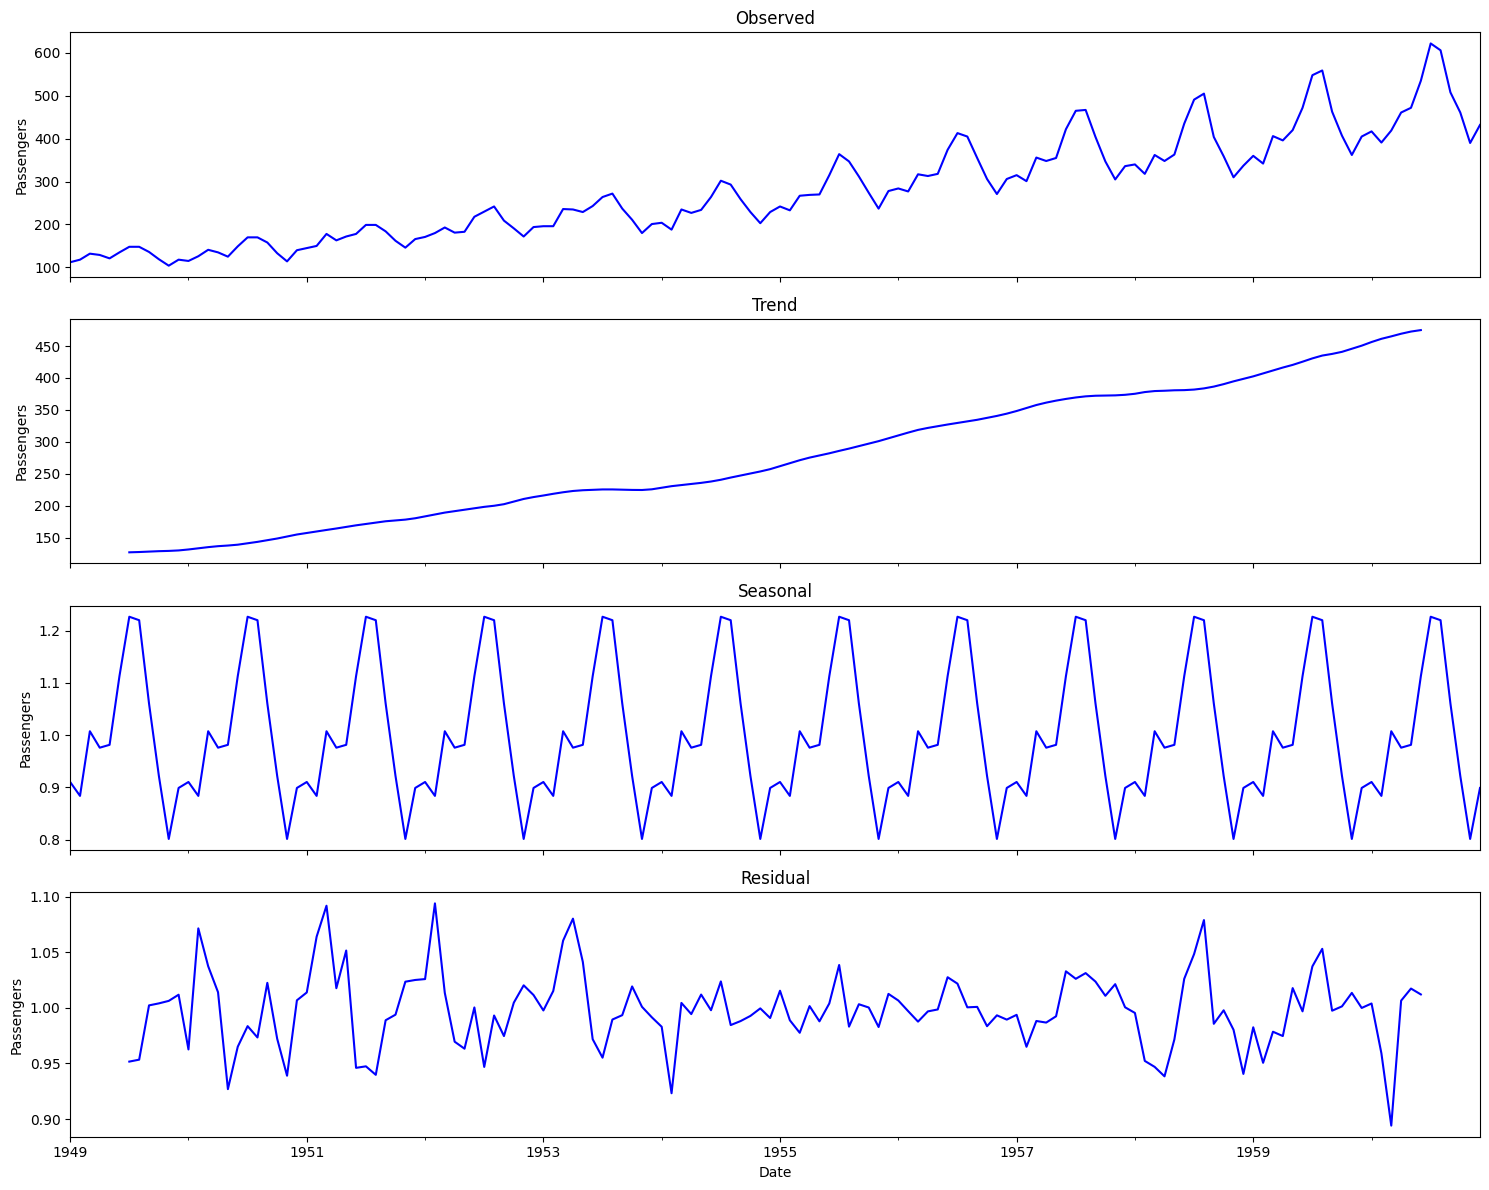

In [17]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
decomposition_multiplicative.observed.plot(ax=ax1, title='Observed', color='blue')
decomposition_multiplicative.trend.plot(ax=ax2, title='Trend', color='blue')
decomposition_multiplicative.seasonal.plot(ax=ax3, title='Seasonal', color='blue')
decomposition_multiplicative.resid.plot(ax=ax4, title='Residual', color='blue')
ax1.set_ylabel('Passengers')
ax2.set_ylabel('Passengers')
ax3.set_ylabel('Passengers')
ax4.set_ylabel('Passengers')
ax4.set_xlabel('Date')
plt.tight_layout()
plt.show()


The multiplicative decomposition provides a more satisfactory breakdown of the time series:

* **Trend:** Shows a linear upward trajectory, indicating growing air passenger numbers.
* **Seasonal:** Displays an annual cycle, reflecting regular seasonal variations in air travel.
* **Residual:** Appears more random and less structured, indicating a better fit with the multiplicative model.

**Transforming the Time Series to an Additive Model**

When dealing with a multiplicative model, it's often useful to transform the series using the logarithm function. This transformation converts the multiplicative relationships into additive ones, making it easier to analyze the series using standard techniques.

In [18]:
# Transform the series using the logarithm
log_air_passengers = np.log(airpass)

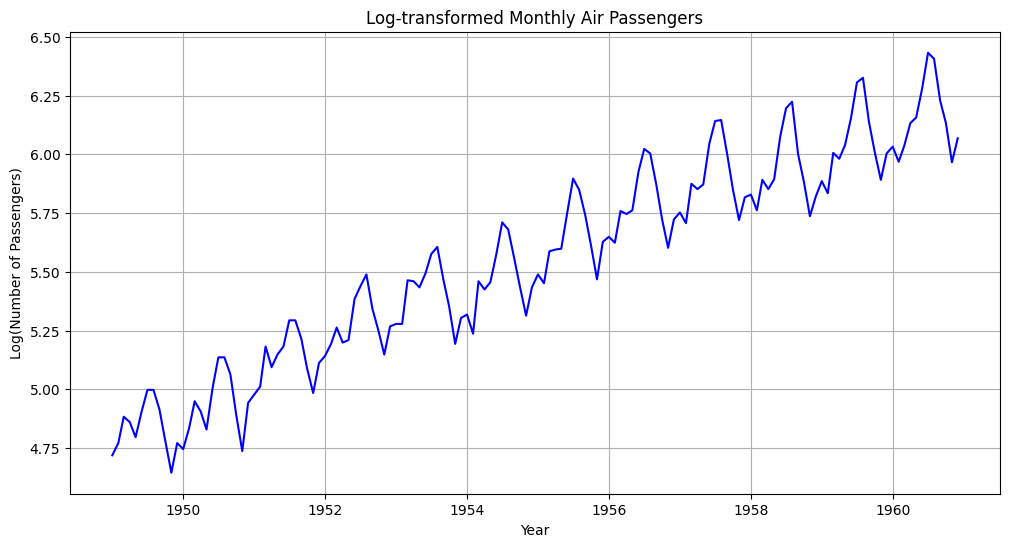

In [19]:
# Plot the transformed series
plt.figure(figsize=(12, 6))
plt.plot(log_air_passengers, linestyle='-', color='blue')
plt.title('Log-transformed Monthly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Log(Number of Passengers)')
plt.grid(True)
plt.show()

By applying the logarithmic transformation, we observe that the seasonality now maintains a constant magnitude over time, indicating an additive model. The `seasonal` attribute of the `seasonal_decompose` function provides access to the seasonality values, which we can use to seasonally adjust the series.

In [20]:
# Apply the seasonal_decompose function to the log-transformed series
decomposition_log = seasonal_decompose(log_air_passengers, model='additive')

In [21]:
# Seasonal coefficients are subtracted from the log-transformed series
seasonally_adjusted_log = log_air_passengers - decomposition_log.seasonal

In [41]:
# Revert the log transformation to find the original series
seasonally_adjusted = np.exp(seasonally_adjusted_log)

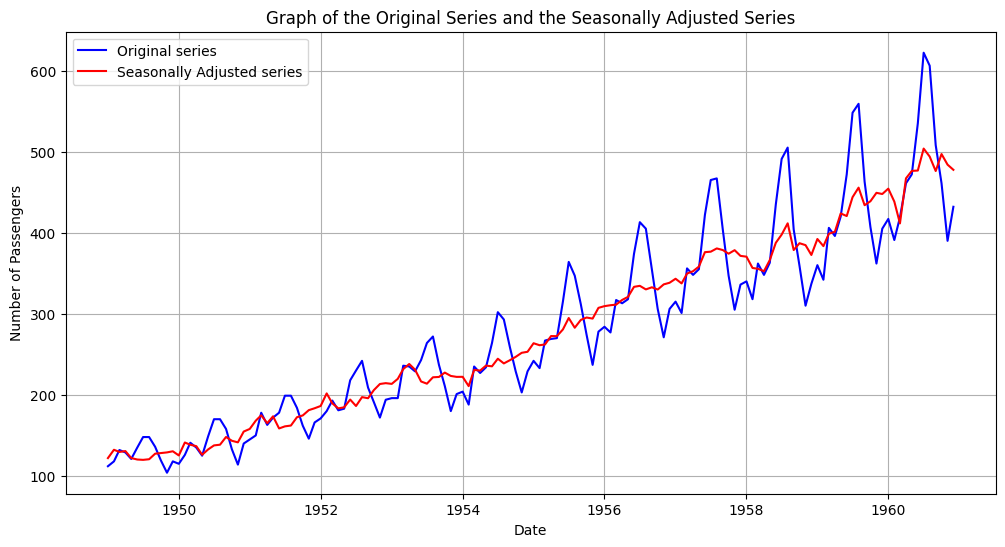

In [22]:
# Plot the original and seasonally adjusted series
plt.figure(figsize=(12, 6))
plt.plot(airpass, color='blue', label='Original series')
plt.plot(seasonally_adjusted, color='red', label='Seasonally Adjusted series')
plt.title('Graph of the Original Series and the Seasonally Adjusted Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

**Moving Averages Method**

The moving averages method is a widely used technique in time series analysis to smooth out short-term fluctuations and highlight longer-term trends or cycles. This method calculates the average of a subset of data points, known as a "window," and moves this window across the dataset to produce a series of averages.

In pandas, the `rolling` method allows you to define the window size and, when combined with the `mean` method, calculates the moving average. The `center` parameter in the `rolling` function specifies whether to position the window such that the current point is at the center (half the values before and half after) or at the end (taking the last n values).

Using the rolling method combined with mean, we calculate the moving average centered over 12 months.

**Calculate the Moving Average**

In [23]:
# Calculate the moving average centered over 12 months
airpassengers_ma = log_air_passengers.rolling(window=12, center=True).mean()

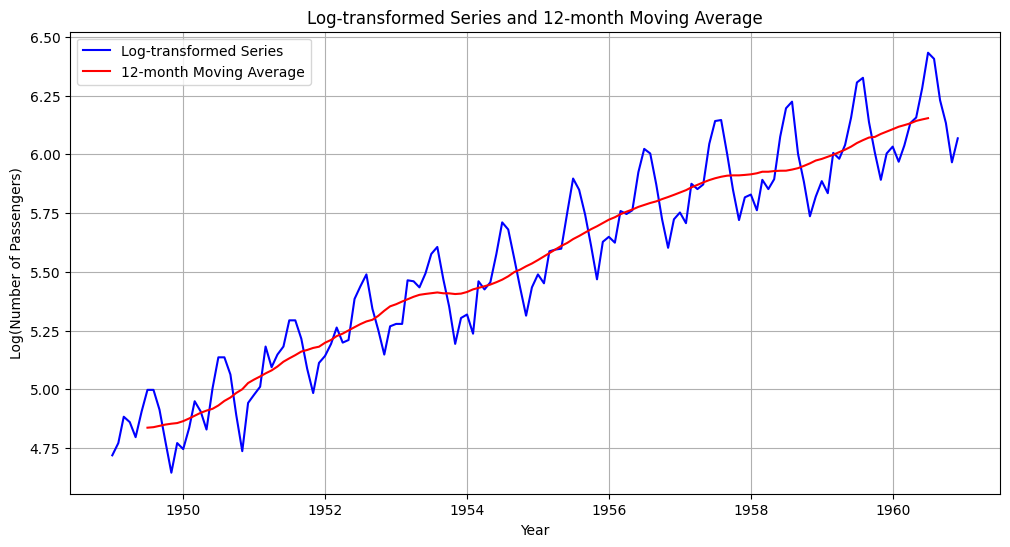

In [24]:
# Plot the moving average and original log-transformed series
plt.figure(figsize=(12, 6))
plt.plot(log_air_passengers, label='Log-transformed Series', linestyle='-', color='blue', )
plt.plot(airpassengers_ma, label='12-month Moving Average', linestyle='-', color='red')
plt.title('Log-transformed Series and 12-month Moving Average')
plt.xlabel('Year')
plt.ylabel('Log(Number of Passengers)')
plt.legend()
plt.grid(True)
plt.show()


The red line represents the 12-month moving average of the log-transformed series. This is calculated by averaging each data point with its surrounding 11 points (5 before and 5 after, including the point itself).

**Reverting to the Original Series and Plotting**

To revert the log-transformed series and the moving average back to their original scales, we apply the exponential function. This transformation helps us visualize the series in its original context and compare the smoothed trend with the actual data.

In [25]:
# Revert the log-transformed series and moving average to their original scale
original_series = np.exp(log_air_passengers)
moving_average_series = np.exp(airpassengers_ma)

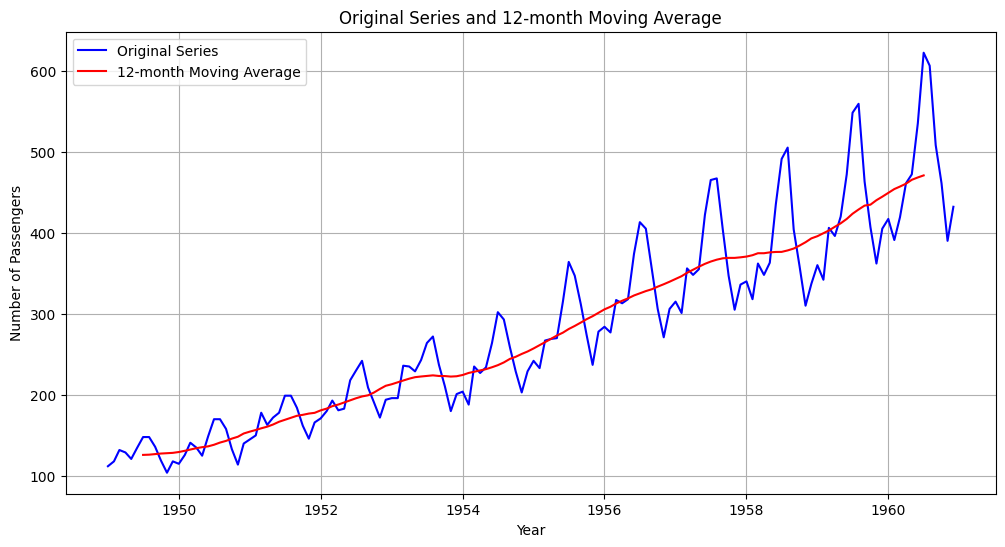

In [26]:
# Plot the original series and moving average
plt.figure(figsize=(12, 6))
plt.plot(original_series, color='blue', label='Original Series')
plt.plot(moving_average_series, color='red', label='12-month Moving Average')
plt.legend()
plt.title('Original Series and 12-month Moving Average')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

**Identifying Seasonality with Moving Averages**

The moving average method allows us to identify the trend in the time series, which in our case is linearly increasing. To identify seasonality, we look for periodic patterns that repeat over a fixed period. Here, we assume a seasonality period of 12 months, corresponding to the monthly data. The process of identifying seasonality involves calculating seasonal coefficients that represent the typical variation for each month of the year.

In [42]:
# Calculate the difference between the series and its moving average
log_air_passengers_diff = log_air_passengers - airpassengers_ma
# Display the first 10 values of the difference
log_air_passengers_diff.head(30)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,0.161034
1949-08-01,0.158831
1949-09-01,0.068807


The `NaN` values appear because the moving average calculation requires a full window of 12 data points. For the first few months, there aren't enough previous values to compute a 12-month moving average. These NaN values are expected and do not indicate an error. They simply reflect the initial period where the moving average cannot be calculated due to insufficient data. `Positive` values indicate that the actual log-transformed number of passengers in those months was higher than the 12-month moving average. A `negative` value indicates that the actual log-transformed number of passengers in that month was lower than the 12-month moving average.

**Handling Missing Values in the Moving Average Series**

As explained above, the moving average calculation results in missing values at the ends of the series. This is because the moving average requires `surrounding` values, which are not available at the beginning and end of the series. To proceed with a clean dataset, we need to remove these missing values.

In [28]:
# Remove missing values from the difference series
cleaned_log_air_passengers_diff = log_air_passengers_diff.dropna()

In [29]:
# Display the first 10 values of the cleaned series
cleaned_log_air_passengers_diff.head(10)

,#Passengers
Month,
1949-07-01,0.161034
1949-08-01,0.158831
1949-09-01,0.068807
1949-10-01,-0.070221
1949-11-01,-0.208742
1949-12-01,-0.085158
1950-01-01,-0.119133
1950-02-01,-0.039333
1950-03-01,0.061597


**Converting the Series to a DataFrame and Adding a Month Column**

With the missing data removed, we can proceed to calculate the seasonal coefficients. To perform operations on the `cleaned_log_air_passengers_diff` series, we will convert it to a DataFrame.

In [30]:
# Convert the cleaned series to a DataFrame
df_air_passengers_diff = cleaned_log_air_passengers_diff.to_frame(name='Log_Passenger_Diff')

In [31]:
# Add a 'month' column to the DataFrame
df_air_passengers_diff['month'] = df_air_passengers_diff.index.month

In [32]:
# Display the first 10 lines of the DataFrame
df_air_passengers_diff.head(10)

,Log_Passenger_Diff,month
Month,,
1949-07-01,0.161034,7
1949-08-01,0.158831,8
1949-09-01,0.068807,9
1949-10-01,-0.070221,10
1949-11-01,-0.208742,11
1949-12-01,-0.085158,12
1950-01-01,-0.119133,1
1950-02-01,-0.039333,2
1950-03-01,0.061597,3


**Calculating and Centering Seasonal Coefficients**

With the month information added to each observation, we can now calculate the seasonal coefficients for each month of the year. This involves averaging the log-transformed differences for each month and then centering these coefficients by subtracting the overall mean.

In [33]:
# Calculate the average per month using groupby and mean methods
seasonal_coefficients = df_air_passengers_diff.groupby('month').mean()

In [34]:
# Center the seasonal coefficients by subtracting the overall mean
centered_seasonal_coefficients = seasonal_coefficients - seasonal_coefficients.mean()

# Display the centered seasonal coefficients
centered_seasonal_coefficients


,Log_Passenger_Diff
month,
1,-0.085812
2,-0.114509
3,0.017670
4,-0.013351
5,-0.009395
6,0.114873
7,0.215677
8,0.203615
9,0.063776


**Creating a Seasonally Adjusted Series**

With the centered seasonal coefficients calculated, the next step is to adjust the log-transformed series for these seasonal variations. We will create a vector to store the seasonal coefficients, replicate it for the length of the series, and subtract it to obtain the seasonally adjusted series.

In [35]:
# Create a vector of size 144 filled with zeros
seasonal_adjustment_vector = np.zeros(len(log_air_passengers))

In [36]:
# Using a for loop, fill the vector with seasonal coefficients for each year
for i in range(len(log_air_passengers)):
    month_index = log_air_passengers.index[i].month - 1  # month is 1-based, array is 0-based
    seasonal_adjustment_vector[i] = centered_seasonal_coefficients.iloc[month_index, 0]


In [37]:
# Subtract the seasonal coefficients to get the seasonally adjusted log series
log_passengers_seasonal_adjusted = log_air_passengers - seasonal_adjustment_vector

In [38]:
# Convert the seasonally adjusted log series back to the original scale
passengers_seasonal_adjusted = np.exp(log_passengers_seasonal_adjusted)

In [39]:
# Display the first 10 values of the seasonally adjusted series
log_passengers_seasonal_adjusted.head(10)

,#Passengers
Month,
1949-01-01,4.804311
1949-02-01,4.885193
1949-03-01,4.865132
1949-04-01,4.873164
1949-05-01,4.805186
1949-06-01,4.790402
1949-07-01,4.781536
1949-08-01,4.793597
1949-09-01,4.848879


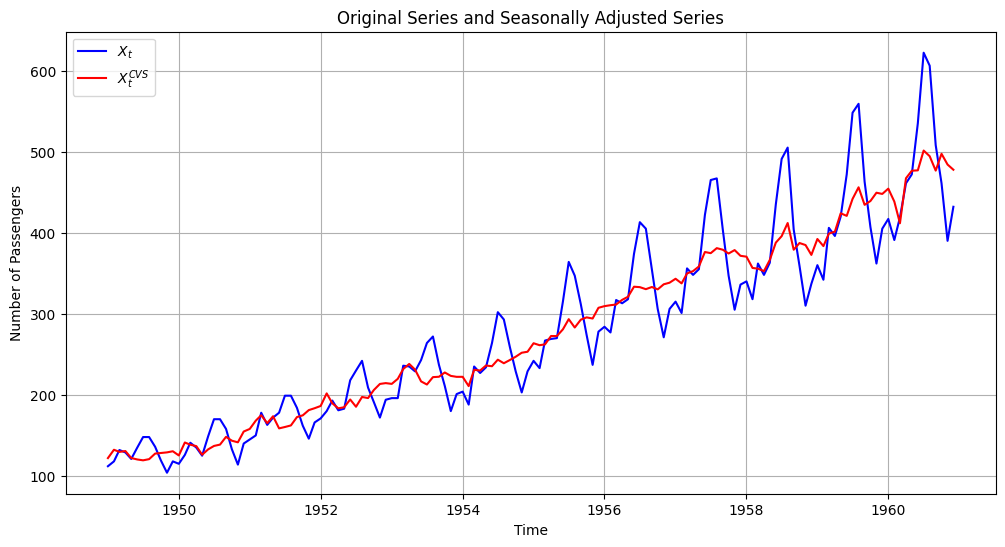

In [40]:
# Plot the original series and the seasonally adjusted series
plt.figure(figsize=(12, 6))
plt.plot(airpass, '-', color='blue', label='$X_t$')
plt.plot(passengers_seasonal_adjusted, color='red', label='$X_t^{CVS}$')
plt.title('Original Series and Seasonally Adjusted Series')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# **Conclusion:**

The seasonally adjusted series ($X_t^{CVS}$) highlights underlying trends by removing seasonal effects. This adjustment reveals significant changes in air passenger numbers, such as the declines observed in 1958 and 1960, which would have been difficult to detect in the original series due to seasonal fluctuations. By providing a clearer view of the data, seasonal adjustment facilitates more accurate trend analysis and better-informed decision-making.

This concludes that given data sets  on the seasonal adjustment of time series method. The steps and approach  demonstrated here can be applied to other time series datasets to enhance the clarity and accuracy of trend analysis.